<a href="https://colab.research.google.com/github/SemanticApp/quantitative-investment-analysis/blob/main/Quantitative_Investment_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Hedge Fund Manager: From Idea to Operating Fund**

A manager moves through investment strategy, fund formation, capital raising, portfolio construction, risk management, performance measurement, and repeated review.

# **1. Define the Investment Strategy**

Before buying anything, the manager decides what kind of fund this is.

**Examples:**

Long/short equity
Global macro
Quantitative equity
Event-driven
Relative value
Distressed debt
Multi-strategy

Then define the investment thesis.

***For the project:***

Use historical market data, fundamental information, quantitative signals, and simulations to identify attractive risk-adjusted investment opportunities.

The manager also defines constraints such as:

Target return
Maximum acceptable risk
Leverage
Liquidity
Position limits
Investment horizon

# **2. Establish the Fund**

Now the investment idea becomes an actual business.

The manager needs the fund structure, legal documents, service providers, banking/custody arrangements, administration, compliance, and reporting infrastructure.

This is where the Emerging Fund information you showed earlier fits.

# **3. Raise Capital**

The manager then seeks investors.

Potential investors might include:

High-net-worth individuals
Family offices
Institutions
Pension funds
Endowments
Foundations

The manager must explain:

What do we invest in?

Why should investors believe our strategy has an edge?

What are the risks?

This is where a track record becomes extremely important.

# **4. Define the Investment Universe**

Now the manager decides:

What securities are we actually allowed to consider?

For the project, this might be the ten-stock universe:

In [11]:
# ---------------------------------------------------------
# Define our investment universe
# 9 individual companies + SPY as the market benchmark
# ---------------------------------------------------------

tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "JPM",
    "JNJ",
    "XOM",
    "WMT",
    "KO",
    "AMZN",
    "SPY"
]

# **5. Research and Generate Investment Ideas**
A real hedge fund might consider thousands of securities.

The universe is then filtered based on things like:

Market capitalization,
Liquidity,
Sector,
Geography,
Financial quality,
Volatility

**Sources might include:**

**Quantitative**
Returns,
Volatility,
Momentum,
Valuation,
Earnings,
Volume,
Correlations

**Fundamental**
Revenue,
Profit,
Debt,
Margins,
Management,
Competitive position

**Qualitative / Alternative Information**
News,
Industry developments,
Corporate announcements,
Regulatory changes,
Supply-chain information,

**This is exactly where your HedgeFundSim experience becomes interesting:** the simulator explicitly gives you fundamentals, price behavior, rumors, and news.

# **6. Test the Strategy**

A professional manager doesn't simply say:

"This looks like a good stock."

They ask:

Does the investment thesis actually work?

**Then evaluate:**

Return,
Volatility,
Sharpe ratio,
Maximum drawdown,
Win rate,
MAE/RMSE for predictive models,
Out-of-sample performance,

This is where regression and backtesting work belongs.

# **7. Construct the Portfolio**

Even if the manager identifies ten attractive stocks, you don't necessarily buy all ten equally.

The manager decides:

How much capital should each position receive?

**For example:**

Security	Weight
AAPL	15%

MSFT	15%

NVDA	10%

JPM	10%

JNJ	10%

XOM	10%

WMT	10%

KO	5%

AMZN	10%

Cash	5%

This is portfolio construction.

**The key idea:**

A good investment idea can still be a bad position size.

That's why you gave MSE a smaller allocation in your simulator even when you liked its growth prospects.

# **8. Execute the Trades**

Now the manager actually buys and sells.

Execution involves:

Order size,
Price,
Liquidity,
Timing,
Transaction costs,
Market impact

The theoretical portfolio isn't necessarily the portfolio you actually get.

This is where real-world implementation can differ from a backtest.

# **9. Manage Risk**

This happens every day, not just after a trade goes wrong.

A manager monitors:

Position risk

Is one stock becoming too large?

Sector risk

Are we accidentally making one giant technology bet?

Market risk

What happens if the whole market falls 20%?

Liquidity risk

Can we sell what we own?

Model risk

What happens if our model assumptions are wrong?

Event risk

What happens if a company experiences a regulatory or legal shock?

Drawdown

How far are we below our previous portfolio peak?

This is one of the biggest differences between:

Stock picking

and

Fund management.

# **10. Monitor the Portfolio**

The manager continuously asks:

Is the original investment thesis still valid?

# **11. Measure Performance**

The manager needs much more than:

"We made money."

They calculate:

Absolute return

How much did the fund make?

Relative return

Did we outperform the benchmark?

Risk-adjusted return

Did we earn enough return for the risk taken?

Maximum drawdown

How bad was the worst decline from peak to trough?

Volatility

How variable were the returns?

Sharpe ratio

How much excess return did we generate per unit of volatility?

And critically:

Was our performance caused by skill, market exposure, or luck?

# **12. Rebalance and Exit**

Positions don't remain at their original weights forever.

# **13. Report to Investors**

A hedge fund manager has to communicate results.

Investors want to know:

Return,
Risk,
Major positions,
What worked,
What didn't,
Why performance changed,
What the manager is doing next

A sophisticated report does not hide bad results.

It might say:

"Our technology allocation underperformed because..."

That transparency is part of professional fund management.

# **14. Start the Cycle Again**

The process is continuous:

A hedge fund is not a stock-picking contest.

It is a system for making decisions under uncertainty.

The manager's job is not merely to find investments that go up. It is to:

identify opportunities → size them appropriately → control risk → test assumptions → monitor evidence → adapt → communicate results.

And that's exactly why the project you've been building is becoming much stronger: it now has research, modeling, backtesting, Monte Carlo simulation, event-driven decisions, position sizing, and portfolio management, rather than just a prediction model.

In [17]:
import yfinance as yf

company_names = {}
for ticker_symbol in tickers:
    try:
        ticker_info = yf.Ticker(ticker_symbol).info
        company_names[ticker_symbol] = ticker_info.get('longName', 'N/A')
    except Exception as e:
        company_names[ticker_symbol] = f"Error fetching name: {e}"

for ticker_symbol, name in company_names.items():
    print(f"{ticker_symbol}: {name}")

AAPL: Apple Inc.
MSFT: Microsoft Corporation
NVDA: NVIDIA Corporation
JPM: JPMorgan Chase & Co.
JNJ: Johnson & Johnson
XOM: ExxonMobil Holdings Corporation
WMT: Walmart Inc.
KO: The Coca-Cola Company
AMZN: Amazon.com, Inc.
SPY: State Street SPDR S&P 500 ETF Trust


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download two years of historical market data
prices = yf.download(
    tickers,
    period="2y",
    auto_adjust=True,
    progress=False
)

print(prices.head())

Price            Close                                                 \
Ticker            AAPL        AMZN         JNJ         JPM         KO   
Date                                                                    
2024-08-19  224.016022  178.220001  150.824539  206.762619  65.174217   
2024-08-20  224.630890  178.880005  151.325317  205.870117  65.552147   
2024-08-21  224.521835  180.110001  152.525269  205.946915  65.731674   
2024-08-22  222.667343  176.130005  153.394516  207.895081  65.504913   
2024-08-23  224.958176  177.039993  155.076294  209.507324  65.939522   

Price                                                                  ...  \
Ticker            MSFT        NVDA         SPY        WMT         XOM  ...   
Date                                                                   ...   
2024-08-19  415.755829  129.786072  546.668457  72.571892  111.891640  ...   
2024-08-20  418.981018  127.040619  545.779541  73.379120  108.162865  ...   
2024-08-21  418.330139  1

In [23]:
close = prices["Close"]

returns = close.pct_change().dropna()

In [13]:
# Extract only adjusted closing prices
close = prices["Close"]

print(close.head())

Ticker            AAPL        AMZN         JNJ         JPM         KO  \
Date                                                                    
2024-08-19  224.016022  178.220001  150.824539  206.762619  65.174217   
2024-08-20  224.630890  178.880005  151.325317  205.870117  65.552147   
2024-08-21  224.521835  180.110001  152.525269  205.946915  65.731674   
2024-08-22  222.667343  176.130005  153.394516  207.895081  65.504913   
2024-08-23  224.958176  177.039993  155.076294  209.507324  65.939522   

Ticker            MSFT        NVDA         SPY        WMT         XOM  
Date                                                                   
2024-08-19  415.755829  129.786072  546.668457  72.571892  111.891640  
2024-08-20  418.981018  127.040619  545.779541  73.379120  108.162865  
2024-08-21  418.330139  128.288559  547.655090  74.068222  107.473740  
2024-08-22  409.857758  123.536377  543.356873  74.402924  108.304466  
2024-08-23  411.080780  129.157120  549.130188  74.52106

In [14]:
# Calculate daily percentage returns
returns = close.pct_change()

# Remove the first row containing missing returns
returns = returns.dropna()

print(returns.head())

Ticker          AAPL      AMZN       JNJ       JPM        KO      MSFT  \
Date                                                                     
2024-08-20  0.002745  0.003703  0.003320 -0.004317  0.005799  0.007757   
2024-08-21 -0.000485  0.006876  0.007930  0.000373  0.002739 -0.001553   
2024-08-22 -0.008260 -0.022098  0.005699  0.009460 -0.003450 -0.020253   
2024-08-23  0.010288  0.005167  0.010964  0.007755  0.006635  0.002984   
2024-08-26  0.001499 -0.008699  0.002925  0.003939  0.015045 -0.007918   

Ticker          NVDA       SPY       WMT       XOM  
Date                                                
2024-08-20 -0.021154 -0.001626  0.011123 -0.033325  
2024-08-21  0.009823  0.003436  0.009391 -0.006371  
2024-08-22 -0.037043 -0.007848  0.004519  0.007730  
2024-08-23  0.045499  0.010625  0.001588  0.013859  
2024-08-26 -0.022494 -0.002384  0.004359  0.021406  


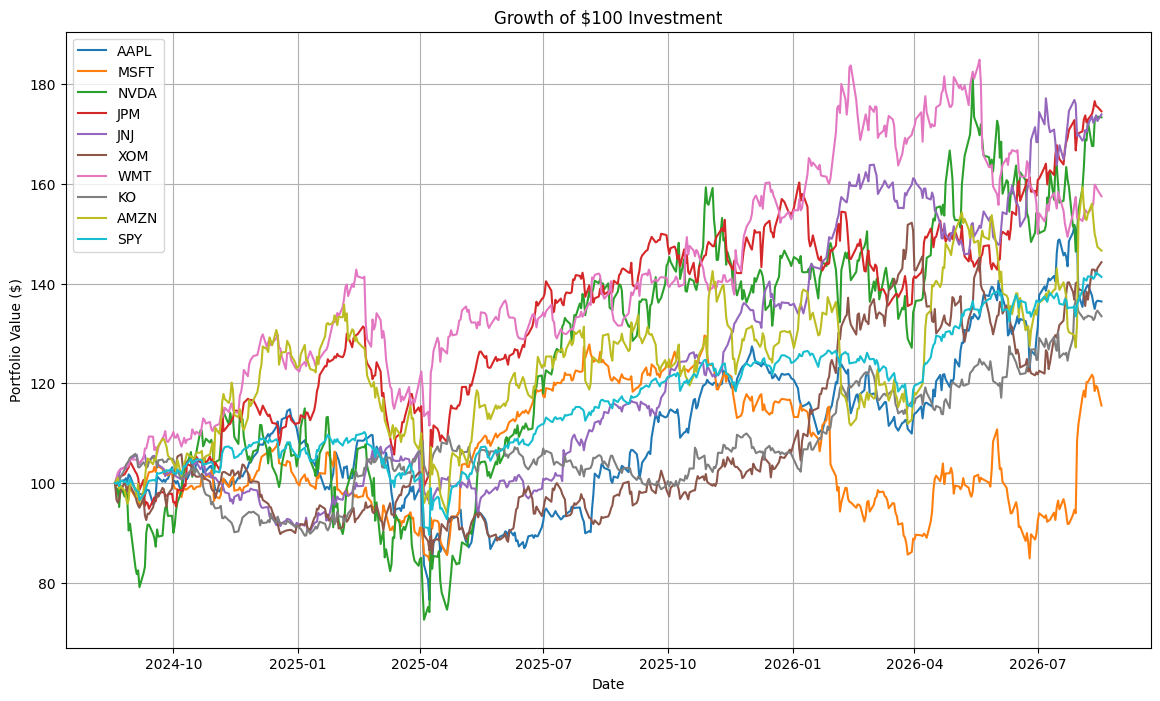

In [15]:
# Normalize every investment to $100
normalized = (
    close / close.iloc[0]
) * 100

plt.figure(figsize=(14, 8))

for ticker in tickers:
    plt.plot(
        normalized.index,
        normalized[ticker],
        label=ticker
    )

plt.title(
    "Growth of $100 Investment"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Average daily return
mean_daily_return = returns.mean()

# Daily volatility
daily_volatility = returns.std()

# Approximate annualized return
annual_return = (
    mean_daily_return * 252
)

# Approximate annualized volatility
annual_volatility = (
    daily_volatility * np.sqrt(252)
)

summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

print(summary)

        Annual Return  Annual Volatility
Ticker                                  
AAPL         0.197951           0.287805
AMZN         0.250700           0.341181
JNJ          0.297399           0.187948
JPM          0.312808           0.250675
KO           0.161659           0.178650
MSFT         0.113998           0.288746
NVDA         0.379821           0.450859
SPY          0.188541           0.166570
WMT          0.258374           0.240193
XOM          0.216238           0.248586


In [19]:
summary["Maximum Daily Gain"] = (
    returns.max()
)

summary["Maximum Daily Loss"] = (
    returns.min()
)

summary["Positive Days"] = (
    returns > 0
).mean()

In [20]:
summary = summary.sort_values(
    "Annual Return",
    ascending=False
)

print(summary)

        Annual Return  Annual Volatility  Maximum Daily Gain  \
Ticker                                                         
NVDA         0.379821           0.450859            0.187227   
JPM          0.312808           0.250675            0.115445   
JNJ          0.297399           0.187948            0.061932   
WMT          0.258374           0.240193            0.095488   
AMZN         0.250700           0.341181            0.153206   
XOM          0.216238           0.248586            0.049916   
AAPL         0.197951           0.287805            0.153288   
SPY          0.188541           0.166570            0.105019   
KO           0.161659           0.178650            0.049958   
MSFT         0.113998           0.288746            0.155067   

        Maximum Daily Loss  Positive Days  
Ticker                                     
NVDA             -0.169682       0.531062  
JPM              -0.074838       0.561122  
JNJ              -0.075917       0.547094  
WMT        

In [21]:
summary["Return/Risk Ratio"] = (
    summary["Annual Return"]
    /
    summary["Annual Volatility"]
)

summary = summary.sort_values(
    "Return/Risk Ratio",
    ascending=False
)

print(summary)

        Annual Return  Annual Volatility  Maximum Daily Gain  \
Ticker                                                         
JNJ          0.297399           0.187948            0.061932   
JPM          0.312808           0.250675            0.115445   
SPY          0.188541           0.166570            0.105019   
WMT          0.258374           0.240193            0.095488   
KO           0.161659           0.178650            0.049958   
XOM          0.216238           0.248586            0.049916   
NVDA         0.379821           0.450859            0.187227   
AMZN         0.250700           0.341181            0.153206   
AAPL         0.197951           0.287805            0.153288   
MSFT         0.113998           0.288746            0.155067   

        Maximum Daily Loss  Positive Days  Return/Risk Ratio  
Ticker                                                        
JNJ              -0.075917       0.547094           1.582346  
JPM              -0.074838       0.561122 

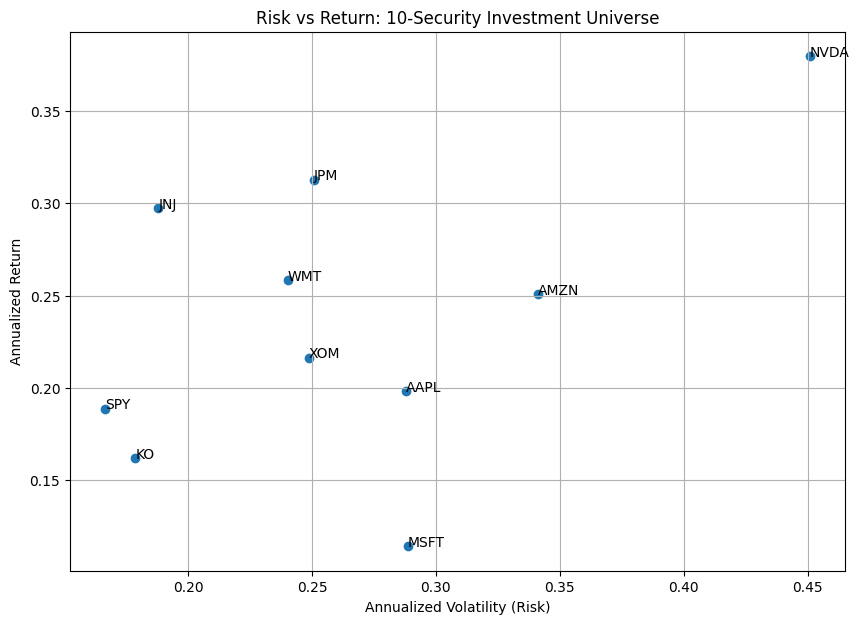

In [22]:
plt.figure(figsize=(10, 7))

plt.scatter(
    summary["Annual Volatility"],
    summary["Annual Return"]
)

# Label each security
for ticker in summary.index:

    plt.annotate(
        ticker,
        (
            summary.loc[
                ticker,
                "Annual Volatility"
            ],
            summary.loc[
                ticker,
                "Annual Return"
            ]
        )
    )

plt.xlabel(
    "Annualized Volatility (Risk)"
)

plt.ylabel(
    "Annualized Return"
)

plt.title(
    "Risk vs Return: 10-Security Investment Universe"
)

plt.grid(True)

plt.show()

In [24]:
# ---------------------------------------------------------
# MONTE CARLO SETTINGS
# ---------------------------------------------------------

# Number of future trading days to simulate
days = 30

# Number of possible futures for EACH stock
simulations = 10_000

# Dictionary where we will store the final simulated prices
monte_carlo_results = {}

In [25]:
# ---------------------------------------------------------
# MONTE CARLO SIMULATION FOR ALL 10 SECURITIES
# ---------------------------------------------------------

for ticker in tickers:

    # Current/latest stock price
    current_price = close[ticker].iloc[-1]

    # Historical average daily return
    mean_return = returns[ticker].mean()

    # Historical daily volatility
    volatility = returns[ticker].std()

    # Create space for:
    # 31 days x 10,000 simulations
    paths = np.zeros(
        (days + 1, simulations)
    )

    # Every simulation starts at today's price
    paths[0] = current_price

    # Simulate each future trading day
    for day in range(1, days + 1):

        # Generate 10,000 random daily returns
        random_returns = np.random.normal(
            mean_return,
            volatility,
            simulations
        )

        # Calculate the next day's simulated prices
        paths[day] = (
            paths[day - 1]
            * (1 + random_returns)
        )

    # Save only the FINAL prices from all 10,000 simulations
    monte_carlo_results[ticker] = paths[-1]

In [26]:
# ---------------------------------------------------------
# SUMMARIZE MONTE CARLO RESULTS
# ---------------------------------------------------------

mc_summary = []

for ticker in tickers:

    current_price = close[ticker].iloc[-1]

    final_prices = monte_carlo_results[ticker]

    # Average simulated ending price
    mean_final = np.mean(final_prices)

    # Median simulated ending price
    median_final = np.median(final_prices)

    # Probability that simulated ending price
    # is greater than today's price
    probability_profit = np.mean(
        final_prices > current_price
    )

    # Downside and upside percentiles
    percentile_5 = np.percentile(
        final_prices,
        5
    )

    percentile_95 = np.percentile(
        final_prices,
        95
    )

    # Expected percentage change
    expected_change = (
        mean_final / current_price
    ) - 1

    # Store results
    mc_summary.append({
        "Ticker": ticker,
        "Current Price": current_price,
        "Mean Final Price": mean_final,
        "Median Final Price": median_final,
        "Expected Change": expected_change,
        "Probability Profit": probability_profit,
        "5th Percentile": percentile_5,
        "95th Percentile": percentile_95
    })

In [27]:
mc_summary = pd.DataFrame(mc_summary)

mc_summary = mc_summary.set_index(
    "Ticker"
)

print(mc_summary)

        Current Price  Mean Final Price  Median Final Price  Expected Change  \
Ticker                                                                         
AAPL       305.589996        312.755888          310.857238         0.023449   
MSFT       480.350006        486.330795          484.531740         0.012451   
NVDA       225.009995        235.156227          232.445323         0.045092   
JPM        360.959991        374.359193          372.899204         0.037121   
JNJ        262.369995        272.023953          271.397902         0.036795   
XOM        161.460007        165.567189          164.995519         0.025438   
WMT        114.330002        117.950448          117.507098         0.031667   
KO          86.980003         88.618236           88.413071         0.018835   
AMZN       261.309998        268.870781          267.312136         0.028934   
SPY        772.669983        790.840762          789.074471         0.023517   

        Probability Profit  5th Percent

In [28]:
# ---------------------------------------------------------
# CONVERT MONTE CARLO OUTCOMES TO RETURN MEASURES
# ---------------------------------------------------------

mc_summary["Downside %"] = (
    mc_summary["5th Percentile"]
    / mc_summary["Current Price"]
    - 1
)

mc_summary["Upside %"] = (
    mc_summary["95th Percentile"]
    / mc_summary["Current Price"]
    - 1
)

# **Rank by Probability and Profit**

In [30]:
mc_ranking = mc_summary.sort_values(
    "Probability Profit",
    ascending=False
)

display(
    mc_ranking[
        [
            "Expected Change",
            "Probability Profit",
            "Downside %",
            "Upside %"
        ]
    ].style.format({
        "Expected Change": "{:.2%}",
        "Probability Profit": "{:.2%}",
        "Downside %": "{:.2%}",
        "Upside %": "{:.2%}"
    })
)

,Expected Change,Probability Profit,Downside %,Upside %
Ticker,,,,
JNJ,3.68%,70.01%,-6.82%,14.89%
JPM,3.71%,64.98%,-10.00%,19.04%
SPY,2.35%,64.78%,-6.94%,12.16%
WMT,3.17%,63.30%,-10.43%,18.07%
KO,1.88%,60.66%,-8.24%,12.55%
XOM,2.54%,59.85%,-11.27%,17.52%
NVDA,4.51%,58.26%,-19.89%,33.40%
AMZN,2.89%,57.54%,-16.10%,24.01%
AAPL,2.34%,57.26%,-13.50%,19.67%


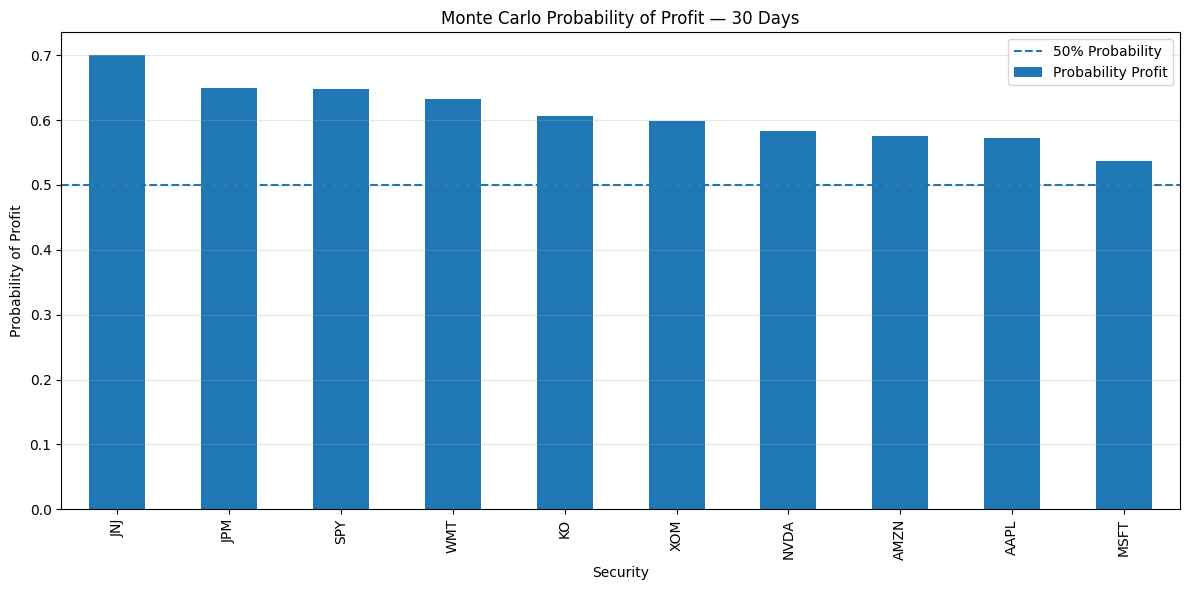

In [31]:
plt.figure(figsize=(12, 6))

mc_ranking[
    "Probability Profit"
].plot(
    kind="bar"
)

plt.title(
    "Monte Carlo Probability of Profit — 30 Days"
)

plt.xlabel("Security")

plt.ylabel("Probability of Profit")

plt.axhline(
    0.50,
    linestyle="--",
    label="50% Probability"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [32]:
comparison = summary.join(
    mc_summary[
        [
            "Expected Change",
            "Probability Profit"
        ]
    ]
)

I began with ten investments, quantitatively screened them based on historical risk and return, tested predictive models out-of-sample, simulated uncertainty using Monte Carlo, and used the combined evidence to construct a final portfolio.

Historical Market Data
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Exploratory Analysis
        ↓
Multiple Regression
        ↓
Train/Test Evaluation
        ↓
Backtesting
        ↓
Monte Carlo Simulation
        ↓
Risk Analysis
        ↓
Investment Comparison
        ↓
Conclusion + Limitations

In [34]:
risk_table = mc_summary[
    [
        "Probability Profit",
        "Expected Change",
        "Downside %",
        "Upside %"
    ]
].copy()

risk_table = risk_table.sort_values(
    "Downside %",
    ascending=False
)

display(
    risk_table.style.format({
        "Probability Profit": "{:.2%}",
        "Expected Change": "{:.2%}",
        "Downside %": "{:.2%}",
        "Upside %": "{:.2%}"
    })
)

,Probability Profit,Expected Change,Downside %,Upside %
Ticker,,,,
JNJ,70.01%,3.68%,-6.82%,14.89%
SPY,64.78%,2.35%,-6.94%,12.16%
KO,60.66%,1.88%,-8.24%,12.55%
JPM,64.98%,3.71%,-10.00%,19.04%
WMT,63.30%,3.17%,-10.43%,18.07%
XOM,59.85%,2.54%,-11.27%,17.52%
AAPL,57.26%,2.34%,-13.50%,19.67%
MSFT,53.63%,1.25%,-14.26%,18.43%
AMZN,57.54%,2.89%,-16.10%,24.01%


## **Monte Carlo for all 10**

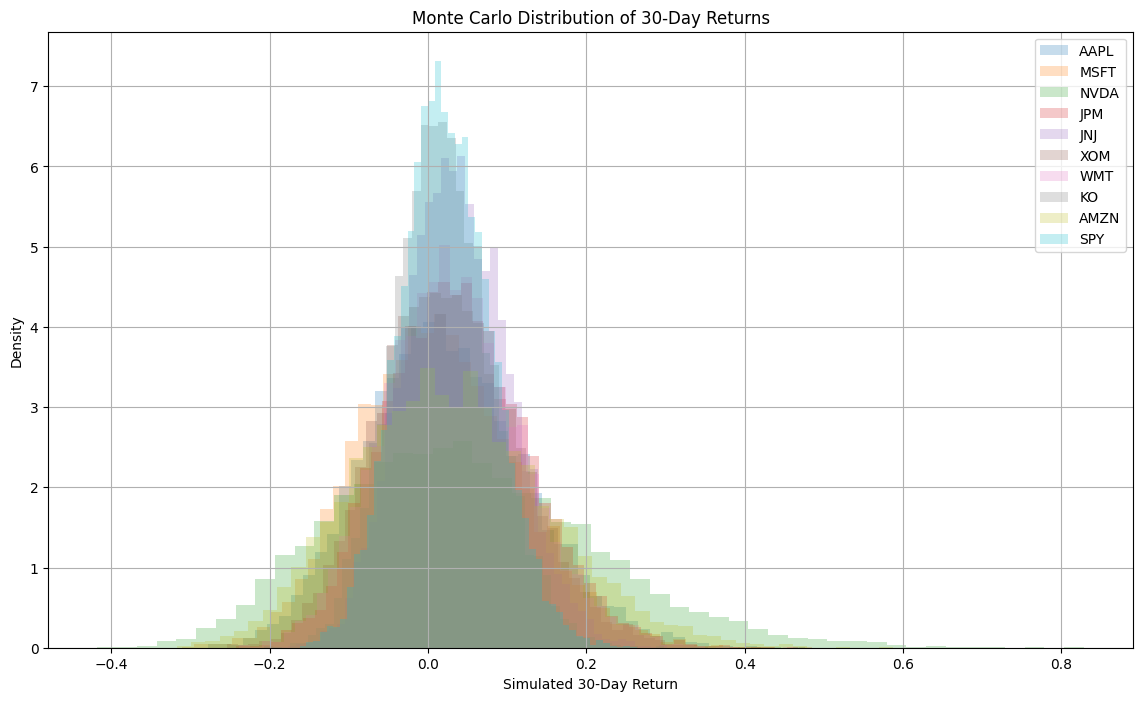

In [35]:
plt.figure(figsize=(14, 8))

for ticker in tickers:

    current_price = close[ticker].iloc[-1]

    simulated_returns = (
        monte_carlo_results[ticker]
        / current_price
        - 1
    )

    plt.hist(
        simulated_returns,
        bins=50,
        alpha=0.25,
        density=True,
        label=ticker
    )

plt.title(
    "Monte Carlo Distribution of 30-Day Returns"
)

plt.xlabel(
    "Simulated 30-Day Return"
)

plt.ylabel(
    "Density"
)

plt.legend()

plt.grid(True)

plt.show()

**Don't simply choose:**

Top three historical returns.

Instead combine: **bold text**

Historical evidence
Annualized return
Annualized volatility
Return/risk ratio
Monte Carlo evidence
Expected 30-day change
Probability of profit
5th-percentile downside
95th-percentile upside
Regression evidence
Test R²
MAE
RMSE

Monte Carlo simulation of a portfolio containing multiple stocks while preserving their correlations.

That's considerably more sophisticated because AAPL, MSFT, NVDA, SPY, etc. don't move independently.

For the LinkedIn/GitHub project, I'd ultimately do both:

**Monte Carlo #1**: 10 individual securities × 10,000 futures → compare opportunities.

**Monte Carlo #2**: Construct a multi-stock portfolio → simulate 10,000 possible portfolio outcomes, incorporating the historical covariance/correlation structure.

That second simulation would tie the entire project together and make the final question:

"What is the probability that our quantitatively selected portfolio produces a positive return, and what is its downside risk?"

## **Building and Backtesting a Simple Quantitative Investment Strategy**
**Research Question**

Can commonly available market features—returns, moving-average behavior, volatility, and trading volume—provide useful information for evaluating and forecasting short-term stock returns, and how does that evidence compare with a Monte Carlo view of future outcomes?

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "AAPL"

df = yf.download(
    ticker,
    period="2y",
    auto_adjust=True,
    progress=False
)

# Flatten columns if Yahoo returns a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df["Return"] = df["Close"].pct_change()

df["MA5"] = (
    df["Close"]
    .rolling(5)
    .mean()
)

df["MA_Distance"] = (
    (df["Close"] - df["MA5"])
    / df["MA5"]
)

df["Volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Tomorrow"] = (
    df["Return"]
    .shift(-1)
)

df = df.dropna()

print(df.head())

# Calculate and print the probability of a positive daily return from historical data
probability_positive_return_historical = (df["Return"] > 0).mean()
print(f"\nProbability of positive daily return (historical data): {probability_positive_return_historical:.2%}")

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2024-09-17  214.991531  215.100619  212.720536  213.960166   45519300   
2024-09-18  218.859192  220.862439  215.735315  215.745241   59894900   
2024-09-19  226.971344  227.913475  222.766528  223.123542   66781300   
2024-09-20  226.306885  231.156317  225.731695  228.062205  318679900   
2024-09-23  224.591232  227.546506  223.936704  225.454010   54146000   

Price         Return         MA5  MA_Distance  Volatility  Tomorrow  
Date                                                                 
2024-09-17  0.002173  218.381195    -0.015522    0.010821  0.017990  
2024-09-18  0.017990  217.990460     0.003985    0.011676  0.037066  
2024-09-19  0.037066  219.200342     0.035452    0.014485 -0.002928  
2024-09-20 -0.002928  220.330884     0.027123    0.014361 -0.007581  
2024-09-23 -0.007581  222.344037     0.010107    0.014302  0.003974 

## **Figure 1 — Normalized Performance**

Put both investments on a common $100 starting point.

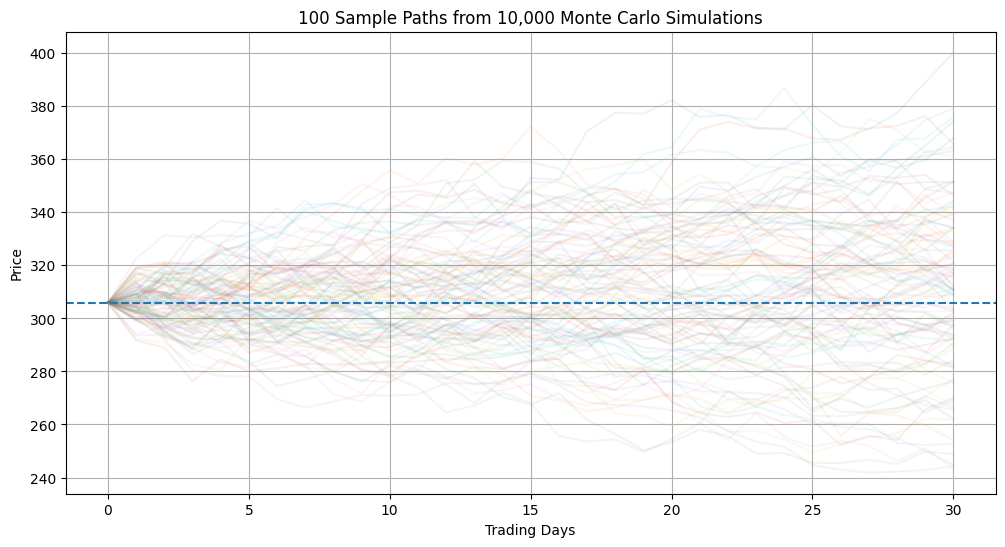

In [10]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(
        paths[:, i],
        alpha=0.08
    )

plt.axhline(
    current_price,
    linestyle="--"
)

plt.title(
    "100 Sample Paths from 10,000 Monte Carlo Simulations"
)

plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.grid(True)
plt.show()

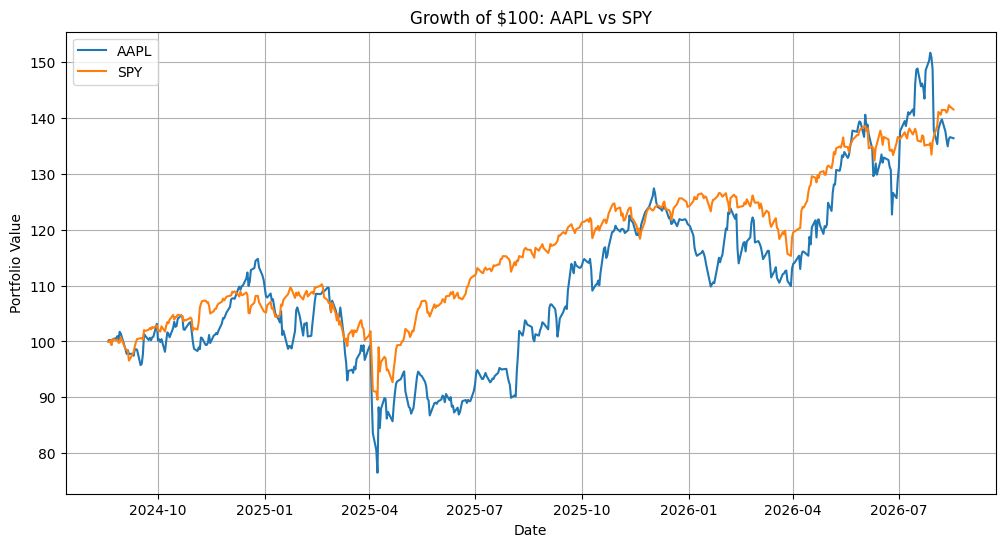

In [2]:
aapl = yf.download(
    "AAPL",
    period="2y",
    auto_adjust=True,
    progress=False
)["Close"]

spy = yf.download(
    "SPY",
    period="2y",
    auto_adjust=True,
    progress=False
)["Close"]

aapl_normalized = aapl / aapl.iloc[0] * 100
spy_normalized = spy / spy.iloc[0] * 100

plt.figure(figsize=(12,6))

plt.plot(aapl_normalized, label="AAPL")
plt.plot(spy_normalized, label="SPY")

plt.title("Growth of $100: AAPL vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

## **Figure 2 — Return Distribution**

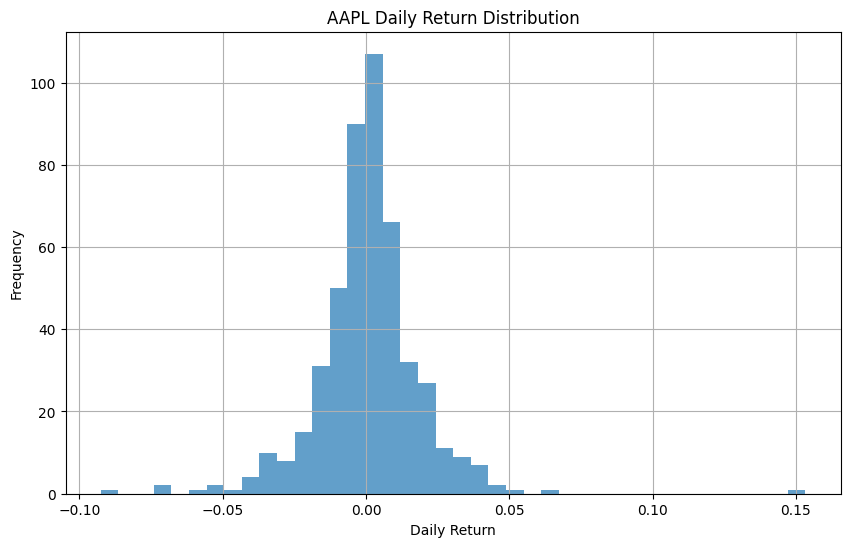

In [3]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Return"],
    bins=40,
    alpha=0.7
)

plt.title("AAPL Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

## **Figure 3 — Rolling Volatility**

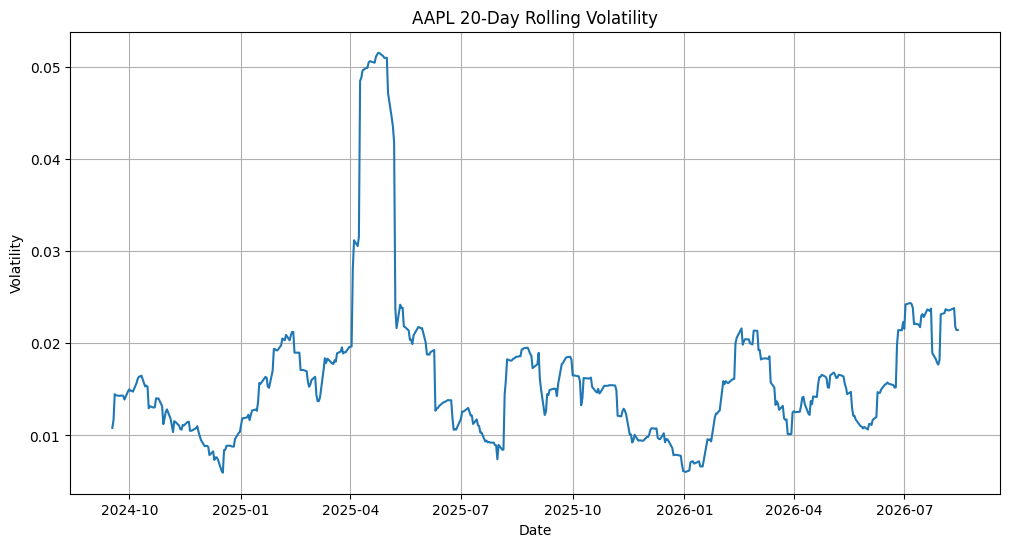

In [4]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df["Volatility"]
)

plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

In [5]:
annual_return = df["Return"].mean() * 252

annual_volatility = (
    df["Return"].std()
    * np.sqrt(252)
)

In [6]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

In [7]:
from sklearn.linear_model import LinearRegression

features = [
    "Return",
    "MA_Distance",
    "Volatility",
    "Volume"
]

X_train = train[features]
y_train = train["Tomorrow"]

X_test = test[features]
y_test = test["Tomorrow"]

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

predictions = model.predict(X_test)

## **Model Evaluation**

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.013472742882833977
RMSE: 0.01848326458425485
R²: -0.017582248384881538


## **Backtesting**

In [9]:
test_results = test.copy()

test_results["Prediction"] = predictions

test_results["Signal"] = (
    test_results["Prediction"] > 0
).astype(int)

test_results["Strategy_Return"] = (
    test_results["Signal"]
    * test_results["Tomorrow"]
)

test_results["Buy_Hold_Return"] = (
    test_results["Tomorrow"]
)

In [10]:
test_results["Strategy_Equity"] = (
    1 + test_results["Strategy_Return"]
).cumprod()

test_results["Buy_Hold_Equity"] = (
    1 + test_results["Buy_Hold_Return"]
).cumprod()

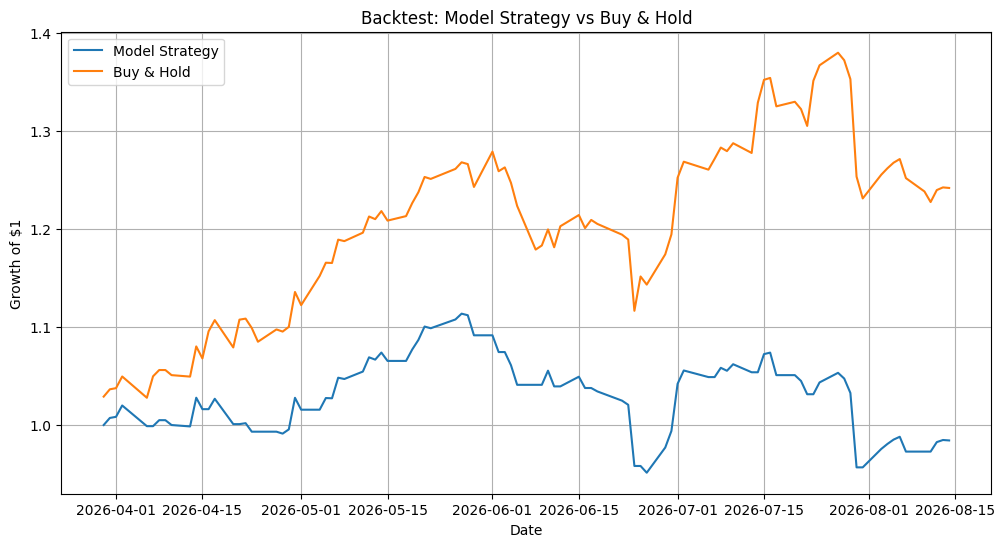

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    test_results["Strategy_Equity"],
    label="Model Strategy"
)

plt.plot(
    test_results["Buy_Hold_Equity"],
    label="Buy & Hold"
)

plt.title("Backtest: Model Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True)

plt.show()

## **Monte Carlo Simulation**

10,000 simulations × 30 trading days

In [12]:
current_price = df["Close"].iloc[-1]

mu = df["Return"].mean()
sigma = df["Return"].std()

days = 30
simulations = 10000

paths = np.zeros(
    (days + 1, simulations)
)

paths[0] = current_price

for day in range(1, days + 1):

    random_returns = np.random.normal(
        mu,
        sigma,
        simulations
    )

    paths[day] = (
        paths[day - 1]
        * (1 + random_returns)
    )

In [13]:
final_prices = paths[-1]

In [6]:
current_price = df["Close"].iloc[-1]

mu = df["Return"].mean()
sigma = df["Return"].std()

days = 30
simulations = 10000

paths = np.zeros(
    (days + 1, simulations)
)

paths[0] = current_price

for day in range(1, days + 1):

    random_returns = np.random.normal(
        mu,
        sigma,
        simulations
    )

    paths[day] = (
        paths[day - 1]
        * (1 + random_returns)
    )

final_prices = paths[-1]

mean_final = np.mean(final_prices)

median_final = np.median(final_prices)

probability_profit = np.mean(
    final_prices > current_price
)

p5 = np.percentile(
    final_prices,
    5
)

p95 = np.percentile(
    final_prices,
    95
)

print(f"Probability of positive return (Monte Carlo Simulation): {probability_profit:.2%}")

Probability of positive return (Monte Carlo Simulation): 58.61%


In [7]:
print(f"Probability of positive return (Monte Carlo Simulation): {probability_profit:.2%}")

Probability of positive return (Monte Carlo Simulation): 58.61%


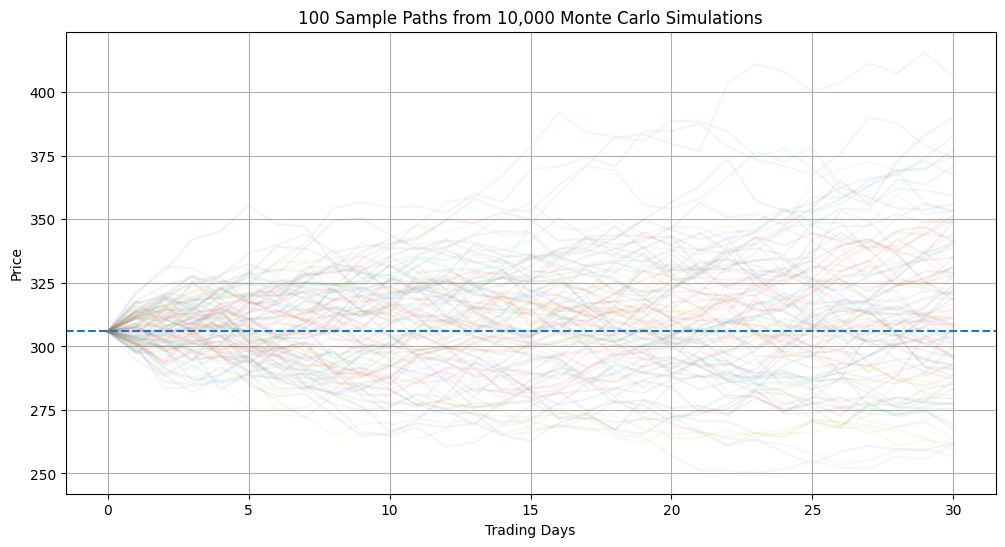

In [15]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(
        paths[:, i],
        alpha=0.08
    )

plt.axhline(
    current_price,
    linestyle="--"
)

plt.title(
    "100 Sample Paths from 10,000 Monte Carlo Simulations"
)

plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.grid(True)
plt.show()

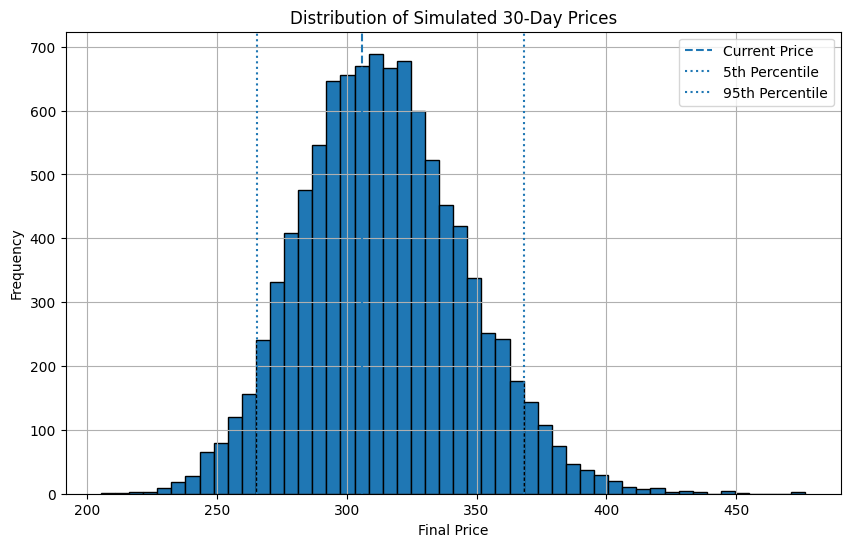

In [16]:
plt.figure(figsize=(10,6))

plt.hist(
    final_prices,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    current_price,
    linestyle="--",
    label="Current Price"
)

plt.axvline(
    p5,
    linestyle=":",
    label="5th Percentile"
)

plt.axvline(
    p95,
    linestyle=":",
    label="95th Percentile"
)

plt.title(
    "Distribution of Simulated 30-Day Prices"
)

plt.xlabel("Final Price")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
print(f"95% Confidence Interval for Final Prices: [{p5:.2f}, {p95:.2f}]")

95% Confidence Interval for Final Prices: [264.38, 369.22]


In [9]:
mc_final_prices_std = np.std(final_prices)

print(f"Historical daily volatility (sigma): {sigma:.4f}")
print(f"Standard deviation of Monte Carlo final prices (after {days} days): {mc_final_prices_std:.2f}")

# A rough estimate of the standard deviation of price after `days`
# for a geometric Brownian motion, assuming current price * sigma * sqrt(days)
projected_std_from_historical_daily_vol = current_price * sigma * np.sqrt(days)
print(f"Projected standard deviation of price based on historical daily volatility after {days} days: {projected_std_from_historical_daily_vol:.2f}")

Historical daily volatility (sigma): 0.0184
Standard deviation of Monte Carlo final prices (after 30 days): 31.76
Projected standard deviation of price based on historical daily volatility after 30 days: 30.78


**Historical daily volatility (sigma):** 0.0184

**Interpretation**: This is the daily standard deviation of returns derived directly from Apple's historical stock data. It means that, on any given day, AAPL's returns have historically fluctuated by approximately 1.84% around its average daily return. A higher sigma indicates greater historical price swings and unpredictability on a daily basis.
Reference: This sigma value is a key input for the Monte Carlo simulation. It quantifies the risk or uncertainty inherent in the stock's daily movements based on past observations.

**Standard deviation of Monte Carlo final prices (after 30 days)**: 31.76

**Interpretation**: This number represents the standard deviation of the distribution of the final prices generated by your 10,000 Monte Carlo simulations after 30 trading days. If you were to plot a histogram of all the final_prices, this value would tell you how spread out those projected prices are.
Reference: This value is a direct output of your simulation. It quantifies the projected risk or uncertainty of the stock's price at the end of the 30-day period, as modeled by the Monte Carlo method. A larger value here suggests a wider range of possible future prices, indicating higher long-term uncertainty in the simulation.

**Projected standard deviation of price based on historical daily volatility after 30 days:** 30.78

**Interpretation**: This is a theoretical estimate of the standard deviation of the stock price after 30 days, calculated using a simplified formula (often derived from geometric Brownian motion assumptions: current_price * sigma * sqrt(days)). It provides a theoretical benchmark for the expected spread of prices given the historical daily volatility and the time horizon.
Reference: This number acts as a validation check for your Monte Carlo simulation. The fact that 31.76 (from MC) is very close to 30.78 (from theoretical projection) suggests that your Monte Carlo simulation is behaving as expected and accurately reflecting the historical volatility in its multi-period price projections. If these two numbers were significantly different, it might indicate an error in the simulation setup or a misunderstanding of the underlying assumptions.
In summary, the sigma (0.0184) is the input for daily volatility, the 31.76 is the output of the Monte Carlo simulation's price spread over 30 days, and the 30.78 is a theoretical expectation for that output. Their closeness confirms that your Monte Carlo model is consistent with the historical volatility.

In [17]:
# Example fund assumptions
starting_aum = 1_000_000

launch_cost = 10_000
annual_operating_cost = 20_000

# Example simulated gross return
gross_return = 0.08

# Portfolio value before fund expenses
gross_value = starting_aum * (1 + gross_return)

# Fund value after setup and operating expenses
net_value = (
    gross_value
    - launch_cost
    - annual_operating_cost
)

net_return = (
    net_value / starting_aum
) - 1

print(f"Gross Return: {gross_return:.2%}")
print(f"Net Return: {net_return:.2%}")

Gross Return: 8.00%
Net Return: 5.00%


AUM = Assets Under Management

In [18]:
aum_levels = [
    100_000,
    250_000,
    500_000,
    1_000_000,
    2_000_000,
    5_000_000,
    10_000_000
]

first_year_cost = 30_000

for aum in aum_levels:

    expense_ratio = (
        first_year_cost / aum
    )

    print(
        f"AUM: ${aum:,.0f} | "
        f"Fixed Costs: {expense_ratio:.2%}"
    )

AUM: $100,000 | Fixed Costs: 30.00%
AUM: $250,000 | Fixed Costs: 12.00%
AUM: $500,000 | Fixed Costs: 6.00%
AUM: $1,000,000 | Fixed Costs: 3.00%
AUM: $2,000,000 | Fixed Costs: 1.50%
AUM: $5,000,000 | Fixed Costs: 0.60%
AUM: $10,000,000 | Fixed Costs: 0.30%
